```markdown
# Superstore Sales Analysis and Forecasting

This notebook performs a comprehensive analysis of Superstore sales data, covering data cleaning, exploratory data analysis (EDA), statistical correlation, customer segmentation, and sales forecasting using the Prophet library.

## Table of Contents

1.  [Libraries Import and Dataset Load](#step-1-libraries-import-aur-dataset-load-karna)
2.  [Data Cleaning & Preprocessing](#step-2-data-cleaning--preprocessing-real-world-cleaning)
3.  [Exploratory Data Analysis (EDA) - Business Insights](#step-3-exploratory-data-analysis-eda---business-insights)
    *   Category-wise Sales and Profit Analysis
    *   Monthly Sales Trend (Seasonality)
4.  [Advanced Statistical Correlation](#step-4-advanced-statistical-correlation)
5.  [Customer Segmentation Analysis](#step-5-customer-segmentation-analysis)
6.  [Time Series Analysis (Sales Trend)](#step-6-time-series-analysis-sales-trend)
7.  [RFM Analysis (Professional Customer Scoring)](#step-7-rfm-analysis-professional-customer-scoring)
8.  [Sales Forecasting with Prophet](#step-8-sales-forecasting-with-prophet)
    *   Data Preparation
    *   Model Training
    *   Future Prediction (6 Months)
9.  [Visualization](#step-9-visualization-result-dekhna)

## 1. Libraries Import and Dataset Load
This section imports necessary Python libraries like `pandas`, `numpy`, `matplotlib`, `seaborn`, and `plotly.express` for data manipulation, visualization, and sets up aesthetic preferences for plots. It then loads the `superstore.csv` dataset.

## 2. Data Cleaning & Preprocessing
This step involves checking for missing values, converting 'Order Date' and 'Ship Date' columns to datetime objects, creating new features like 'Order Year', 'Order Month', and 'Order Day', and calculating 'Profit Margin'.

## 3. Exploratory Data Analysis (EDA) - Business Insights
This section delves into key business questions:
*   **Category-wise Sales and Profit Analysis**: Visualizes total sales and profit across different product categories to identify top-performing departments.
*   **Monthly Sales Trend (Seasonality)**: Analyzes how sales fluctuate over months across different years to identify seasonal patterns.

## 4. Advanced Statistical Correlation
Examines the correlation between 'Sales', 'Quantity', 'Discount', and 'Profit' using a heatmap to understand their relationships, particularly the impact of discounts on profit.

## 5. Customer Segmentation Analysis
Analyzes sales, profit, and order counts by customer segments (Consumer, Corporate, Home Office) to determine which segment should be the primary target.

## 6. Time Series Analysis (Sales Trend)
This step sets 'Order Date' as the index, aggregates monthly sales, and visualizes the overall sales trend over the full timeline using an interactive line plot.

## 7. RFM Analysis (Professional Customer Scoring)
Applies Recency, Frequency, Monetary (RFM) analysis to segment customers based on their purchasing behavior. It calculates Recency (days since last order), Frequency (total orders), and Monetary (total sales) values, and visualizes them to map customer value.

## 8. Sales Forecasting with Prophet
Utilizes the Prophet library for time series forecasting.
*   **Data Preparation**: Prepares the sales data into a format suitable for Prophet (columns 'ds' for date and 'y' for sales).
*   **Model Training**: Initializes and trains the Prophet model with yearly and weekly seasonality.
*   **Future Prediction (6 Months)**: Generates a future dataframe for the next 180 days and makes sales predictions.

## 9. Visualization
Visualizes the sales forecast for the next 6 months using interactive plots from Prophet, including the main forecast graph and component plots (trend, weekly, yearly patterns) to understand underlying sales drivers.
```

Step 1: Libraries Import aur Dataset Load karna
Yahan hum un tools ko bula rahe hain jo hamare data ko process aur visualize karenge.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Aesthetic settings for plots
sns.set_theme(style="whitegrid")
%matplotlib inline

# Dataset load karna (Encoding 'latin1' ya 'cp1252' use karni pad sakti hai)
try:
    df = pd.read_csv('superstore.csv', encoding='latin1')
except:
    df = pd.read_csv('superstore.csv', encoding='cp1252')

# Pehle 5 rows check karein
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Step 2: Data Cleaning & Preprocessing (Real-world Cleaning)
Real datasets mein hamesha errors hote hain. Humein dates ko sahi format mein laana hoga aur unnecessary columns hatane honge.

In [ ]:
# Missing values check karna
print(df.isnull().sum())

# 'Order Date' aur 'Ship Date' ko datetime object mein convert karna
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Naye features create karna (Feature Engineering)
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month_name()
df['Order Day'] = df['Order Date'].dt.day_name()

# Profit Margin calculate karna (Key Business Metric)
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

print("Data cleaning complete. Ready for analysis.")

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Data cleaning complete. Ready for analysis.


Step 3: Exploratory Data Analysis (EDA) - Business Insights
Ab hum real business questions solve karenge.

A. Category-wise Sales aur Profit Analysis
Humein dekhna hai ki kaunsa department sabse zyada profit de raha hai.


In [ ]:
category_analysis = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

# Visualizing using Plotly (Interactive)
fig = px.bar(category_analysis, x='Category', y=['Sales', 'Profit'],
             title='Total Sales vs Profit by Category',
             barmode='group', labels={'value': 'Amount ($)'})
fig.show()

B. Monthly Sales Trend (Seasonality)
Kya sales har mahine badh rahi hain?

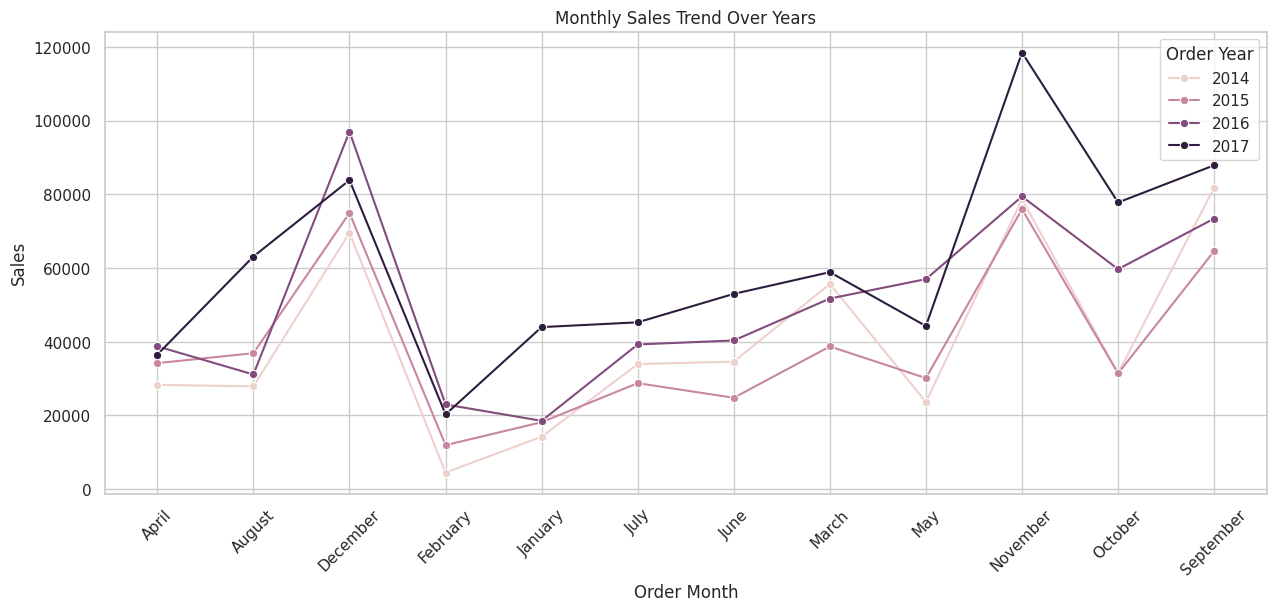

In [ ]:
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_sales, x='Order Month', y='Sales', hue='Order Year', marker='o')
plt.title('Monthly Sales Trend Over Years')
plt.xticks(rotation=45)
plt.show()

Step 4: Advanced Statistical Correlation
Kya Discount dene se profit waqai kam hota hai? Iske liye hum Heatmap use karenge.

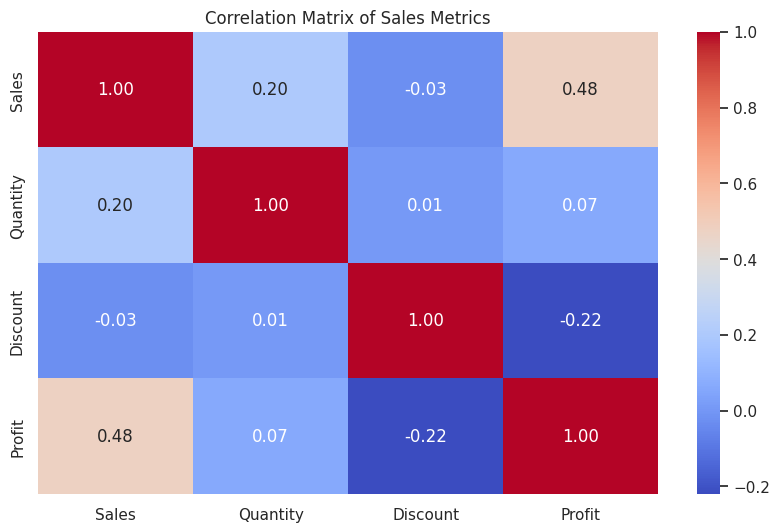

In [ ]:
# Correlation Matrix
plt.figure(figsize=(10, 6))
correlation = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Sales Metrics')
plt.show()

Step 5: Customer Segmentation Analysis
Kaunsa segment (Consumer, Corporate, Home Office) hamara main target hona chahiye?

In [ ]:
segment_analysis = df.groupby('Segment').agg({'Sales':'sum', 'Profit':'sum', 'Order ID':'count'}).reset_index()
segment_analysis.rename(columns={'Order ID': 'Order Count'}, inplace=True)

# Pie Chart for Profit Distribution
fig_pie = px.pie(segment_analysis, values='Profit', names='Segment',
                 title='Profit Distribution by Customer Segment',
                 hole=0.4, color_discrete_sequence=px.colors.sequential.RdBu)
fig_pie.show()

📈 Step 6: Time Series Analysis (Sales Trend)
Business mein ye janna bahut zaroori hai ki sales ka trend kaisa hai—kya hum grow kar rahe hain ya niche ja rahe hain?

In [ ]:
# Order Date ko Index banana Trends ke liye
df_trend = df.set_index('Order Date')

# Monthly Sales ko aggregate karna
monthly_trend = df_trend['Sales'].resample('MS').sum().reset_index()

# Visualization
fig_trend = px.line(monthly_trend, x='Order Date', y='Sales',
                    title='Monthly Sales Trend (Full Timeline)',
                    markers=True, line_shape='spline')

# Peak sales months ko highlight karne ke liye
fig_trend.update_layout(xaxis_title='Timeline', yaxis_title='Total Sales ($)')
fig_trend.show()

💎 Step 7: RFM Analysis (Professional Customer Scoring)
Ye ek advanced marketing technique hai. Hum customers ko teen cheezon par judge karte hain:

Recency (R): Last order kab kiya?

Frequency (F): Kitni baar order kiya?

Monetary (M): Kitna paisa kharch kiya?

In [ ]:
import datetime as dt

# Aaj ki date assume karte hain (dataset ke last date ke ek din baad)
latest_date = df['Order Date'].max() + dt.timedelta(days=1)

# RFM Metrics calculate karna
rfm = df.groupby('Customer Name').agg({
    'Order Date': lambda x: (latest_date - x.max()).days, # Recency
    'Order ID': 'count',                                # Frequency
    'Sales': 'sum'                                      # Monetary
}).reset_index()

rfm.columns = ['Customer Name', 'Recency', 'Frequency', 'Monetary']

# Top 10 High-Value Customers (Monetary base par)
top_customers = rfm.sort_values('Monetary', ascending=False).head(10)

fig_rfm = px.scatter(rfm, x='Recency', y='Frequency', size='Monetary',
                     color='Monetary', hover_name='Customer Name',
                     title='RFM Analysis: Customer Value Mapping')
fig_rfm.show()

In [ ]:
!pip install prophet

2. Data Preparation (Most Important)
Humein data ko Prophet ke hisab se dhalna hoga. Hum daily sales ko aggregate karenge.

In [ ]:
from prophet import Prophet

# Data ko prepare karna: 'Order Date' ko 'ds' aur 'Sales' ko 'y' mein badalna
df_prophet = df.groupby('Order Date')['Sales'].sum().reset_index()
df_prophet.columns = ['ds', 'y']

# Check karein
df_prophet.head()

,ds,y
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


3. Model Training
Ab hum Prophet model ko train karenge. Hum isme 'yearly_seasonality' on rakhenge kyunki retail sales har saal ek pattern follow karti hain.

In [ ]:
# Model initialize karna
model = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=True)

# Data fit karna
model.fit(df_prophet)

print("Model training complete! Agle 6 mahine ki taiyari shuru...")

Model training complete! Agle 6 mahine ki taiyari shuru...


4. Future Prediction (6 Months)
Humein agle 180 din (6 mahine) ka ek khali dataframe banana hoga aur model se prediction mangni hogi.

In [ ]:
# Agle 180 din ka future dataframe banana
future = model.make_future_dataframe(periods=180)

# Prediction (Forecasting) karna
forecast = model.predict(future)

# Forecast ke main columns: ds (date), yhat (prediction), yhat_lower/upper (confidence interval)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1412,2018-06-24,2253.289697,-461.417942,4769.806768
1413,2018-06-25,2459.458551,-163.047419,5377.486844
1414,2018-06-26,1875.146476,-852.844080,4684.143448
1415,2018-06-27,1007.012827,-1681.949404,3916.111939
1416,2018-06-28,2204.463620,-438.645206,4816.801488


📉 Step 9: Visualization (Result Dekhna)
Ab hum interactive graph banayein taaki aap dekh sakein ki agle 6 mahine mein sales upar jayengi ya niche.

In [ ]:
from prophet.plot import plot_plotly, plot_components_plotly

# 1. Main Forecast Graph
fig1 = plot_plotly(model, forecast)
fig1.update_layout(title='Sales Forecast: Next 6 Months', xaxis_title='Date', yaxis_title='Sales ($)')
fig1.show()

# 2. Components Graph (Trend, Weekly, Yearly patterns dekhne ke liye)
# Isse pata chalega ki kis din (e.g. Monday) aur kis mahine sales peak par hoti hain
fig2 = plot_components_plotly(model, forecast)
fig2.show()

/usr/local/lib/python3.12/dist-packages/plotly/io/_json.py:560: UserWarning:

Discarding nonzero nanoseconds in conversion.

